# Perceptron


Learner weights: [-407.88559167   31.38583333   -1.3525    ]
Learner bias: -18.94000000000016


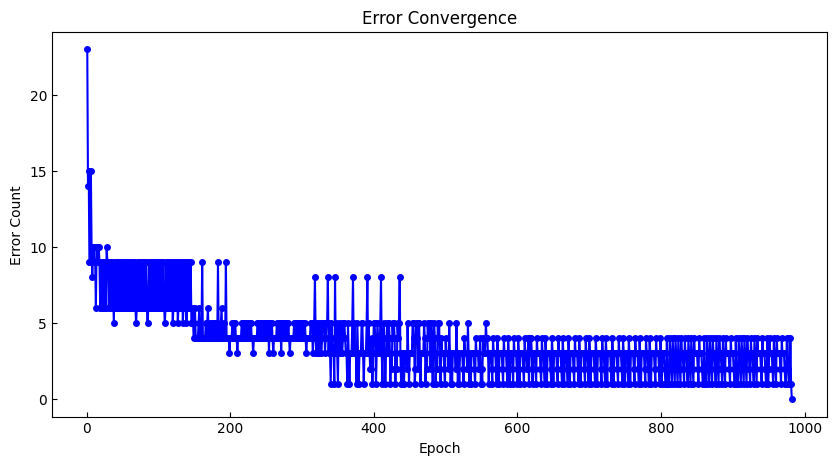

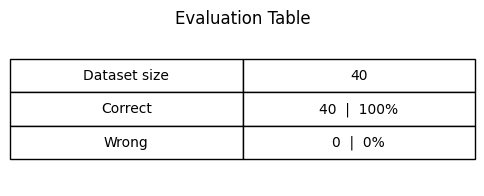

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('perceptron_dataset.csv')
X = df[['Temperature', 'Light', 'CO2']].values
y = df['Occupancy'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=256
)

fig_int1 = go.Figure()
fig_int1.add_trace(go.Scatter3d(
    x=X[y==0, 0], y=X[y==0, 1], z=X[y==0, 2], 
    mode='markers', 
    marker=dict(color='red', size=4, line=dict(color='black', width=1)), 
    name='0'
))
fig_int1.add_trace(go.Scatter3d(
    x=X[y==1, 0], y=X[y==1, 1], z=X[y==1, 2], 
    mode='markers', 
    marker=dict(color='green', size=4, line=dict(color='black', width=1)), 
    name='1'
))
fig_int1.update_layout(
    scene=dict(
        xaxis=dict(title='Temperature', dtick=1),
        yaxis=dict(title='Light', dtick=200),
        zaxis=dict(title='CO2', dtick=500)
    ),
    title="3D Graph Of Dataset", 
    margin=dict(l=0, r=0, b=0, t=40)
)
fig_int1.show()

class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=10000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors = []

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)

    def train(self, X, y):
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0
        for epoch in range(self.epochs):
            total_error = 0
            for idx, x_i in enumerate(X):
                prediction = self.activation(np.dot(x_i, self.weights) + self.bias)
                update = self.lr * (y[idx] - prediction)
                self.weights += update * x_i
                self.bias += update
                if update != 0:
                    total_error += 1
            self.errors.append(total_error)
            if total_error == 0:
                break
        return self.weights, self.bias

model = Perceptron(learning_rate=0.01, epochs=10000)
weights, bias = model.train(X_train, y_train)

print(f"Learner weights: {weights}")
print(f"Learner bias: {bias}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(model.errors) + 1), model.errors, color='blue', linewidth=1.5, marker='o', markersize=4)
plt.title('Error Convergence')
plt.xlabel('Epoch')
plt.ylabel('Error Count')
plt.grid(False)
plt.tick_params(axis='both', direction='in')
plt.show()

y_pred = model.predict(X_test)
correct_count = np.sum(y_pred == y_test)
wrong_count = len(y_test) - correct_count
accuracy_val = accuracy_score(y_test, y_pred)

fig_tab, ax_tab = plt.subplots(figsize=(6, 2))
ax_tab.axis('tight')
ax_tab.axis('off')

table_data = [
    ['Dataset size', len(y_test)],
    ['Correct', f"{correct_count}  |  {accuracy_val*100:.0f}%"],
    ['Wrong', f"{wrong_count}  |  {(1-accuracy_val)*100:.0f}%"]
]

table = ax_tab.table(cellText=table_data, cellLoc='center', loc='center')
table.scale(1, 2)
plt.title("Evaluation Table")
plt.show()

x_grid = np.linspace(15, 25, 20)
y_grid = np.linspace(0, 600, 20)
xx, yy = np.meshgrid(x_grid, y_grid)

fig_int2 = go.Figure()
fig_int2.add_trace(go.Scatter3d(
    x=X[y==0, 0], y=X[y==0, 1], z=X[y==0, 2], 
    mode='markers', 
    marker=dict(color='red', size=4, line=dict(color='black', width=1)), 
    name='0'
))
fig_int2.add_trace(go.Scatter3d(
    x=X[y==1, 0], y=X[y==1, 1], z=X[y==1, 2], 
    mode='markers', 
    marker=dict(color='green', size=4, line=dict(color='black', width=1)), 
    name='1'
))

if weights[2] != 0:
    zz_plane = -(weights[0] * xx + weights[1] * yy + bias) / weights[2]
    fig_int2.add_trace(go.Surface(
        x=xx, y=yy, z=zz_plane, 
        colorscale='Viridis', opacity=0.5, showscale=False, name='Hyperplane'
    ))

fig_int2.update_layout(
    scene=dict(
        xaxis=dict(title='Temperature', range=[15, 25]),
        yaxis=dict(title='Light', range=[0, 600]),
        zaxis=dict(title='CO2', range=[0, 2500])
    ),
    title="Hyperplane In A 3D Graph Of Dataset",
    margin=dict(l=0, r=0, b=0, t=40)
)
fig_int2.show()


## Commentary

While working on this assignment, I learned how to implement a fundamental neural network model from scratch. Now I understood the mathematical relationship between the input features, the learned weights, and the resulting decision boundary in a 3D space. I found out how the learning rate and the number of epochs directly dictate the convergence of the algorithm and the shifting of the hyperplane.

At first, it was not clear why such a simple linear boundary could be restrictive for certain datasets. It turned out that the linear separability of the data is the absolute key to the success of the basic Perceptron, and without it, the model would indefinitely oscillate during training unless a strict epoch limit is enforced.
